In [27]:
import numpy as np
import pandas as pd

# Uncomment and update the file name below after checking the available files
df = pd.read_csv("cleaned_dataset_service.csv")
print(df.head())       # View the first few rows

   Factor Year Factor Number Factor Date Customer ID         Order ID  \
0         2021    IA  000001  2021/01/06      cust01  2020/ON  003184   
1         2021    IT  000273  2021/01/31      cust02  2020/ON  007836   
2         2021    IT  000278  2021/01/31      cust03  2020/ON  001385   
3         2021    IT  000279  2021/01/31      cust04  2020/ON  008522   
4         2021    IT  000287  2021/01/31      cust05  2020/ON  008326   

  Start of rental End of rental Machine ID   Product Group Product Category  \
0      2020-06-03    2021-04-01    CLI1113  Rent Outfitted   Rent Outfitted   
1      2020-11-18    2021-03-09    CLI1097    Rent Special   Rent Outfitted   
2      2020-02-20    2022-01-21    CLI0973       Rent Vans        Rent Vans   
3      2020-11-11    2021-06-18    CLI1098       Rent Vans        Rent Vans   
4      2020-11-30    2021-02-11       A181       Rent Vans        Rent Vans   

   Amount Row Reason  Days Sold Warehouse Unit  Sales Quantity Sales Unit  \
0  1426.0

In [28]:
# Define the mapping from Product Group to segments
from itertools import count


segment_mapping = {
    'Column Lifts': 'Long-term anchors',
    'Hybrid Boom Lifts': 'Long-term anchors',
    'Rent Vans': 'Long-term anchors',
    'Rotating Telehandlers': 'High-value machines',
    'Art. Electric Boom Lifts': 'High-value machines',
    'Art. Diesel Boom Lifts': 'High-value machines',
    'Electric Vertical Lifts': 'Volume workhorses',
    'Fixed Telehandlers': 'Volume workhorses',
    'Telescopic Diesel': 'Volume workhorses',
    'Machines with Operator': 'Operator services',
    'Operators': 'Operator services',
    'Telehandler Accessory': 'Accessories & support',
    'Truck Platform Accessory': 'Accessories & support',
    'Generator Equipment': 'Accessories & support'
}

# Add the Segment column to the dataframe
df['Segment'] = df['Product Group'].map(segment_mapping).fillna('Other')  # Use 'Other' for unmapped groups
# Display the updated dataframe with the new Segment column
print(df[['Product Group', 'Segment']].head())

print((df['Segment'] == 'Other').sum())

    Product Group            Segment
0  Rent Outfitted              Other
1    Rent Special              Other
2       Rent Vans  Long-term anchors
3       Rent Vans  Long-term anchors
4       Rent Vans  Long-term anchors
32371


In [29]:
## Creating variables for RFM analysis
# Monetary: Average Amount per customer-product
# Compute Monetary on the full DataFrame
df["Monetary"] = (
    df
    .groupby(["Customer ID"])["Amount"]
    .transform("mean")
)

# Drop all rows where that computed Monetary is zero
df = df[df["Monetary"] > 0].copy()

In [30]:
# Frequency: Count of unique rental events per customer-product
df["Frequency"] = df.groupby(["Customer ID"])["Order ID"].transform("count")

In [31]:
# Recency: the time since the last purchase
from datetime import timedelta

# Ensure datetime format
df["Factor Date"] = pd.to_datetime(df["Factor Date"])
df["End of rental"] = pd.to_datetime(df["End of rental"])

# Define the fixed reference date for the entire dataset
reference_date = df["Factor Date"].max() + timedelta(days=1)

# Get the latest End of rental per customer-product pair
last_End_of_rental = (
    df.groupby(["Customer ID"])["End of rental"]
    .max()
    .reset_index()
)

# Calculate Recency
last_End_of_rental["Recency"] = (reference_date - last_End_of_rental["End of rental"]).dt.days

# If End of rental is in the future, make Recency negative
last_End_of_rental["Recency"] = np.where(
    last_End_of_rental["End of rental"] > reference_date,
    -(last_End_of_rental["End of rental"] - reference_date).dt.days,
    last_End_of_rental["Recency"]
)

# Merge recency back to the main dataset
df = df.merge(
    last_End_of_rental[["Customer ID","Recency"]],
    on=["Customer ID"],
    how="left"
)

# Quick sanity check
print(f"Reference Date used for Recency: {reference_date.date()}")
cols_to_show = [col for col in ["Customer ID", "End of rental", "Recency"] if col in df.columns]
print(df[cols_to_show].head())

Reference Date used for Recency: 2025-01-01
  Customer ID End of rental  Recency
0      cust01    2021-04-01     1371
1      cust02    2021-03-09      645
2      cust03    2022-01-21      478
3      cust04    2021-06-18     1042
4      cust05    2021-02-11       47


In [32]:
# Create RFM table by aggregating at customer level
rfm_customer = (
    df.groupby(['Customer ID'])[['Recency', 'Frequency', 'Monetary']]
      .first()
      .reset_index()
)
print(rfm_customer.head())

  Customer ID  Recency  Frequency    Monetary
0      cust01     1371          5  837.200000
1      cust02      645         24  403.469167
2      cust03      478         58  503.978621
3      cust04     1042          7  850.008571
4      cust05       47         14  566.964286


In [33]:
labels_recency = ['H', 'M', 'L']  # H for low recency (recent, best), L for high recency (old, worst)
labels_freq_mon = ['L', 'M', 'H']  # L for low (worst), H for high (best)

def lmh_labels(series, labels):
    try:
        return pd.qcut(series, q=3, labels=labels)
    except ValueError:
        return pd.cut(series.rank(method='first'), bins=3, labels=labels)

rfm_customer['Recency_Label'] = lmh_labels(rfm_customer['Recency'], labels_recency)
rfm_customer['Frequency_Label'] = lmh_labels(rfm_customer['Frequency'], labels_freq_mon)
rfm_customer['Monetary_Label'] = lmh_labels(rfm_customer['Monetary'], labels_freq_mon)

print(rfm_customer[['Customer ID', 'Recency', 'Recency_Label', 'Frequency', 'Frequency_Label', 'Monetary', 'Monetary_Label']].head())

  Customer ID  Recency Recency_Label  Frequency Frequency_Label    Monetary  \
0      cust01     1371             L          5               M  837.200000   
1      cust02      645             M         24               H  403.469167   
2      cust03      478             M         58               H  503.978621   
3      cust04     1042             L          7               M  850.008571   
4      cust05       47             H         14               H  566.964286   

  Monetary_Label  
0              H  
1              M  
2              M  
3              H  
4              H  


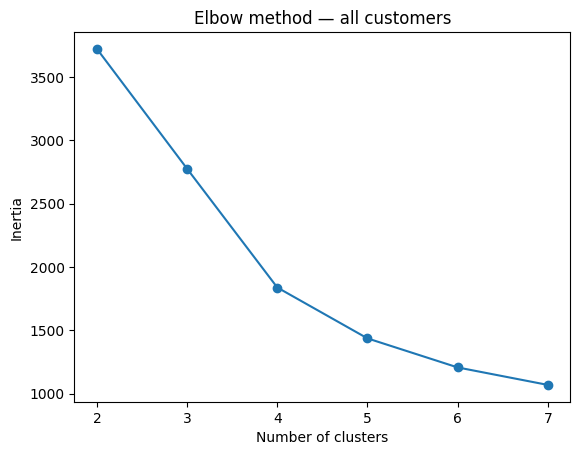

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_customer[['Recency', 'Frequency', 'Monetary']])

# Elbow method
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method — all customers')
plt.show()

        Recency                Frequency                Monetary          \
           mean  median    std      mean  median    std     mean  median   
Cluster                                                                    
0         159.5   135.0  227.2      34.6     7.0   73.4    423.6   368.3   
1         495.4   477.5  419.8      26.6     9.0   65.9   1636.4  1374.8   
2        1028.8  1029.0  253.5       4.7     2.0   13.5    352.7   280.0   
3        -245.8  -150.0  316.4    1426.0  1344.0  537.0    670.1   516.4   

                
           std  
Cluster         
0        260.6  
1        792.6  
2        247.6  
3        457.1  

Cluster sizes:
Cluster
0    823
1    170
2    613
3      5
Name: count, dtype: int64


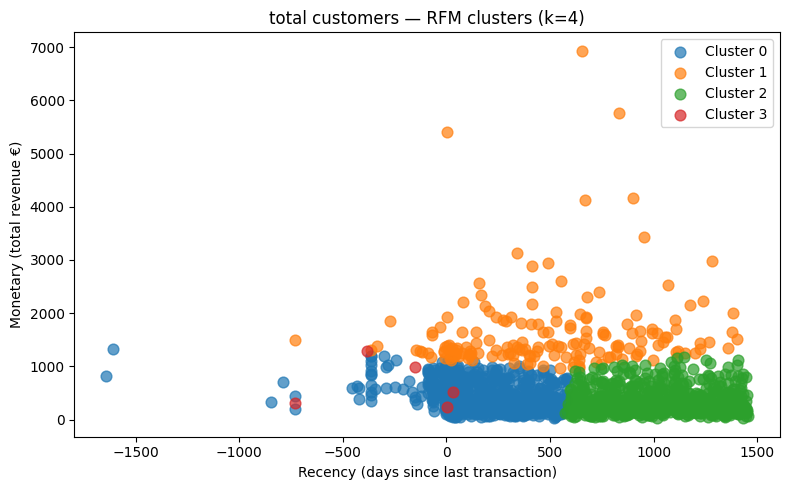

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale
scaler = StandardScaler()
import matplotlib.pyplot as plt

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_customer[['Recency', 'Frequency', 'Monetary']])

# Fit k=4
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
rfm_customer['Cluster'] = km.fit_predict(X_scaled)

# Cluster profiles — unscaled means for interpretability
profile = rfm_customer.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])
print(profile.round(1))

# Cluster sizes
print("\nCluster sizes:")
print(rfm_customer['Cluster'].value_counts().sort_index())

# Quick visual — recency vs monetary, colored by cluster
plt.figure(figsize=(8, 5))
for c in sorted(rfm_customer['Cluster'].unique()):
    subset = rfm_customer[rfm_customer['Cluster'] == c]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {c}', s=60, alpha=0.7)

plt.xlabel('Recency (days since last transaction)')
plt.ylabel('Monetary (total revenue €)')
plt.title('total customers — RFM clusters (k=4)')
plt.legend()
plt.tight_layout()
plt.show()

         n_customers  recency_mean  recency_median  frequency_mean  frequency_median  monetary_mean  monetary_median  active_contracts
Cluster                                                                                                                               
0                726         992.7           979.0             5.8               2.0          349.8            276.3                 0
1               1193         117.8            65.0            50.5              14.0          470.5            432.0               236
2                 25        -373.5          -149.0          1100.6             840.0          861.4            995.8                19
3                207         444.2           411.0            29.3              10.0         1658.9           1388.8                21


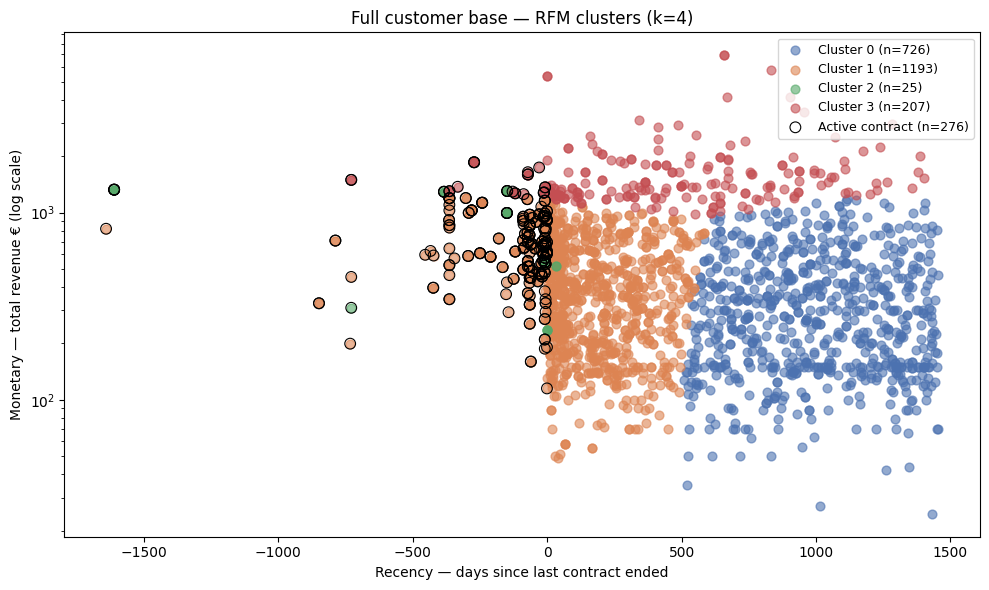

In [43]:
# ── STEP 1: flag and clip negative recency ────────────────────────
rfm = df[['Segment', 'Customer ID', 'Recency', 'Frequency', 'Monetary']].drop_duplicates().rename(columns={'Recency': 'recency', 'Frequency': 'frequency', 'Monetary': 'monetary'})
rfm_full = rfm.copy()
rfm_full['has_active_contract'] = rfm_full['recency'] < 0
# keep recency as-is, negative values preserved

# ── STEP 2: fit k=4 ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_full[['recency', 'frequency', 'monetary']])

km = KMeans(n_clusters=4, random_state=42, n_init='auto')
rfm_full['Cluster'] = km.fit_predict(X_scaled)

# ── STEP 3: cluster profile table ────────────────────────────────
profile = (
    rfm_full.groupby('Cluster')
    .agg(
        n_customers     = ('Customer ID',       'count'),
        recency_mean    = ('recency',            'mean'),
        recency_median  = ('recency',            'median'),
        frequency_mean  = ('frequency',          'mean'),
        frequency_median= ('frequency',          'median'),
        monetary_mean   = ('monetary',           'mean'),
        monetary_median = ('monetary',           'median'),
        active_contracts= ('has_active_contract','sum')
    )
    .round(1)
)
print(profile.to_string())

# ── STEP 4: scatter with log scale + active contract highlight ────
fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52'}

for c in sorted(rfm_full['Cluster'].unique()):
    subset = rfm_full[rfm_full['Cluster'] == c]
    ax.scatter(
        subset['recency'],
        subset['monetary'],
        label=f'Cluster {c} (n={len(subset)})',
        color=colors[c],
        alpha=0.6,
        s=40
    )

# overlay active contracts as black rings
active = rfm_full[rfm_full['has_active_contract']]
ax.scatter(
    active['recency'],
    active['monetary'],
    facecolors='none',
    edgecolors='black',
    s=60,
    linewidths=0.8,
    label=f'Active contract (n={len(active)})',
    zorder=5
)

ax.set_yscale('log')
ax.set_xlabel('Recency — days since last contract ended')
ax.set_ylabel('Monetary — total revenue € (log scale)')
ax.set_title('Full customer base — RFM clusters (k=4)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Analyzing the top 80% revenue generators of the company we can realize that the top 177 customers are not a behaviorally homogeneous group. They share one thing: they're all high revenue. But how they generate that revenue is completely different.

In [35]:
revenue_by_customer = (
    df.groupby("Customer ID", as_index=False)["Amount"]
      .sum()
      .rename(columns={"Amount": "Total_Revenue"})
)

customer_revenue_rfm = (
    rfm_customer.merge(revenue_by_customer, on="Customer ID", how="left")
                .sort_values("Total_Revenue", ascending=False)
                .reset_index(drop=True)
)

total_revenue = customer_revenue_rfm["Total_Revenue"].sum()
customer_revenue_rfm["Cumulative_Revenue"] = customer_revenue_rfm["Total_Revenue"].cumsum()

cutoff_index = customer_revenue_rfm["Cumulative_Revenue"].values.searchsorted(0.8 * total_revenue, side="left")
top_customers_80 = customer_revenue_rfm.iloc[:cutoff_index + 1].copy()

top_share = top_customers_80["Cumulative_Revenue"].iloc[-1] / total_revenue

summary = top_customers_80[["Recency", "Frequency", "Monetary"]].agg(["mean", "std"]).T

print(f"Customers covering ~80% revenue: {len(top_customers_80)}")
print(f"Cumulative revenue share for selection: {top_share:.4f}")
print(summary)

Customers covering ~80% revenue: 177
Cumulative revenue share for selection: 0.8010
                 mean         std
Recency     24.378531  352.543853
Frequency  178.762712  258.050823
Monetary   923.197253  622.507824


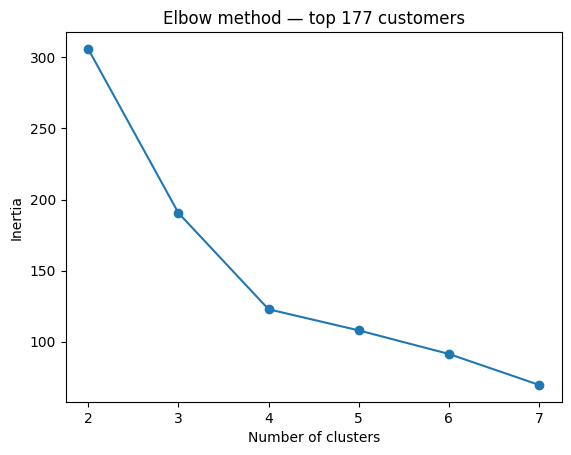

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Filter to top 177
top_customers = revenue_by_customer.head(177)['Customer ID'].tolist()
rfm_top = rfm_customer[rfm_customer['Customer ID'].isin(top_customers)].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_top[['Recency', 'Frequency', 'Monetary']])

# Elbow method
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method — top 177 customers')
plt.show()

        Recency               Frequency               Monetary               
           mean median    std      mean median    std     mean  median    std
Cluster                                                                      
0         906.5  915.0  157.7       4.0    1.0   14.7    246.4   159.0  211.9
1         277.9  345.5  242.3      20.9   10.5   23.8   1695.0  1397.1  579.6
2         -97.8  -65.0  120.6     529.0  447.0  222.0    779.2   848.4  254.1
3          93.3   47.0  206.7      45.6   23.0   55.2    552.6   574.4  258.3

Cluster sizes:
Cluster
0    104
1     18
2      5
3     50
Name: count, dtype: int64


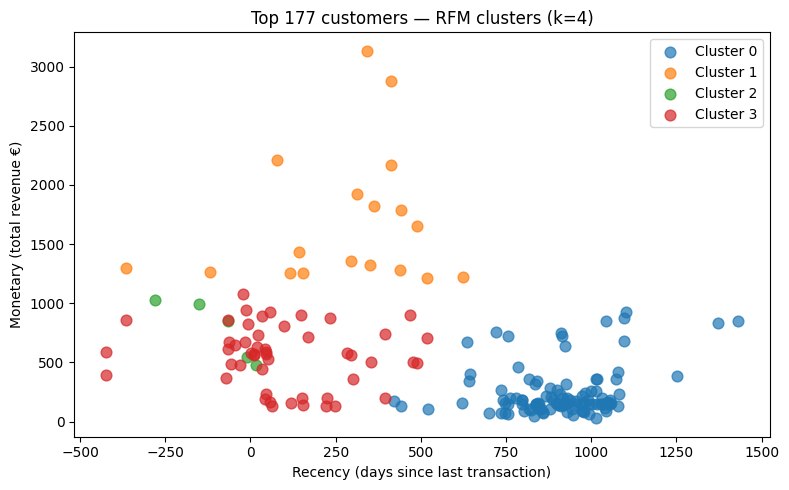

        Recency               Frequency               Monetary               
           mean median    std      mean median    std     mean  median    std
Cluster                                                                      
0         906.5  915.0  157.7       4.0    1.0   14.7    246.4   159.0  211.9
1         277.9  345.5  242.3      20.9   10.5   23.8   1695.0  1397.1  579.6
2         -97.8  -65.0  120.6     529.0  447.0  222.0    779.2   848.4  254.1
3          93.3   47.0  206.7      45.6   23.0   55.2    552.6   574.4  258.3

Cluster sizes:
Cluster
0    104
1     18
2      5
3     50
Name: count, dtype: int64


KeyError: 'recency'

<Figure size 800x500 with 0 Axes>

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale
scaler = StandardScaler()
import matplotlib.pyplot as plt

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_top[['Recency', 'Frequency', 'Monetary']])

# Fit k=4
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
rfm_top['Cluster'] = km.fit_predict(X_scaled)

# Cluster profiles — unscaled means for interpretability
profile = rfm_top.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])
print(profile.round(1))

# Cluster sizes
print("\nCluster sizes:")
print(rfm_top['Cluster'].value_counts().sort_index())

# Quick visual — recency vs monetary, colored by cluster
plt.figure(figsize=(8, 5))
for c in sorted(rfm_top['Cluster'].unique()):
    subset = rfm_top[rfm_top['Cluster'] == c]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f'Cluster {c}', s=60, alpha=0.7)

plt.xlabel('Recency (days since last transaction)')
plt.ylabel('Monetary (total revenue €)')
plt.title('Top 177 customers — RFM clusters (k=4)')
plt.legend()
plt.tight_layout()
plt.show()

# Fit k=4
km = KMeans(n_clusters=4, random_state=42, n_init='auto')
rfm_top['Cluster'] = km.fit_predict(X_scaled)

# Cluster profiles — unscaled means for interpretability
profile = rfm_top.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])
print(profile.round(1))

# Cluster sizes
print("\nCluster sizes:")
print(rfm_top['Cluster'].value_counts().sort_index())

# Quick visual — recency vs monetary, colored by cluster
plt.figure(figsize=(8, 5))
for c in sorted(rfm_top['Cluster'].unique()):
    subset = rfm_top[rfm_top['Cluster'] == c]
    plt.scatter(subset['recency'], subset['monetary'], label=f'Cluster {c}', s=60, alpha=0.7)

plt.xlabel('Recency (days since last transaction)')
plt.ylabel('Monetary (total revenue €)')
plt.title('Top 177 customers — RFM clusters (k=4)')
plt.legend()
plt.tight_layout()
plt.show()